In [3]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 33.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.4/467.4 kB 47.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


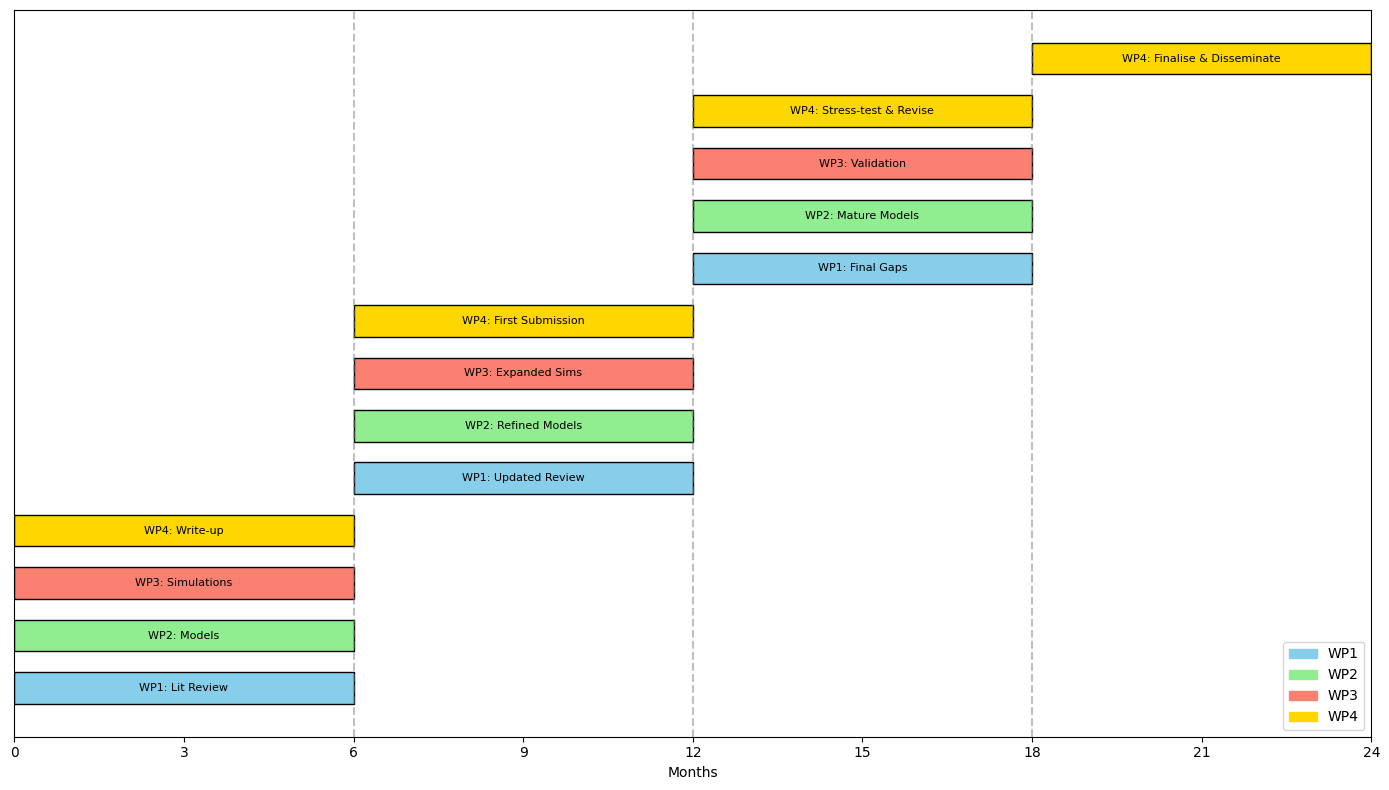

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))

tasks = [
    ('WP1: Lit Review', 0, 6, 'skyblue'),
    ('WP2: Models', 0, 6, 'lightgreen'),
    ('WP3: Simulations', 0, 6, 'salmon'),
    ('WP4: Write-up', 0, 6, 'gold'),
    ('WP1: Updated Review', 6, 12, 'skyblue'),
    ('WP2: Refined Models', 6, 12, 'lightgreen'),
    ('WP3: Expanded Sims', 6, 12, 'salmon'),
    ('WP4: First Submission', 6, 12, 'gold'),
    ('WP1: Final Gaps', 12, 18, 'skyblue'),
    ('WP2: Mature Models', 12, 18, 'lightgreen'),
    ('WP3: Validation', 12, 18, 'salmon'),
    ('WP4: Stress-test & Revise', 12, 18, 'gold'),
    ('WP4: Finalise & Disseminate', 18, 24, 'gold'),
]

for i, (name, start, end, color) in enumerate(tasks):
    ax.barh(i, end - start, left=start, color=color, edgecolor='black', height=0.6)
    ax.text((start + end)/2, i, name, ha='center', va='center', fontsize=8)

ax.set_xlabel('Months')
ax.set_yticks([])
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3))
ax.axvline(6, color='gray', linestyle='--', alpha=0.5)
ax.axvline(12, color='gray', linestyle='--', alpha=0.5)
ax.axvline(18, color='gray', linestyle='--', alpha=0.5)

legend = ax.legend(handles=[
    mpatches.Patch(color='skyblue', label='WP1'),
    mpatches.Patch(color='lightgreen', label='WP2'),
    mpatches.Patch(color='salmon', label='WP3'),
    mpatches.Patch(color='gold', label='WP4'),
], loc='lower right')

plt.tight_layout()
plt.savefig('gantt.pdf', dpi=300)
plt.show()

In [4]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame([
    dict(Task='WP1: Literature Review', Start=0, Finish=6, WP='WP1'),
    dict(Task='WP2: Model Development', Start=0, Finish=6, WP='WP2'),
    dict(Task='WP3: Simulations', Start=0, Finish=6, WP='WP3'),
    dict(Task='WP4: Write-up', Start=0, Finish=6, WP='WP4'),
    dict(Task='WP1: Updated Review', Start=6, Finish=12, WP='WP1'),
    dict(Task='WP2: Refined Models', Start=6, Finish=12, WP='WP2'),
    dict(Task='WP3: Expanded Sims', Start=6, Finish=12, WP='WP3'),
    dict(Task='WP4: First Submission', Start=6, Finish=12, WP='WP4'),
    dict(Task='WP1: Final Gaps', Start=12, Finish=18, WP='WP1'),
    dict(Task='WP2: Mature Models', Start=12, Finish=18, WP='WP2'),
    dict(Task='WP3: Validation', Start=12, Finish=18, WP='WP3'),
    dict(Task='WP4: Stress-test & Revise', Start=12, Finish=18, WP='WP4'),
    dict(Task='WP4: Finalise & Disseminate', Start=18, Finish=24, WP='WP4'),
])

fig = px.timeline(df, x_start='Start', x_end='Finish', y='Task', color='WP',
                  title='Project Gantt Chart')
fig.update_yaxes(autorange='reversed')
fig.show()
fig.write_html('gantt.html')